In [86]:
from cube import Cube, Move, get_reverse_move
from train import CubeNet, check_for_reversal
from pathlib import Path
import torch
from train import get_state, DEVICE

In [87]:
def load_model(path: Path) -> CubeNet:
    model = CubeNet()
    model.load_state_dict(torch.load(path, weights_only=True))
    return model

In [88]:
model = load_model(Path("models/model.pth")).to(DEVICE)
model.eval()

CubeNet(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=324, out_features=2048, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=2048, out_features=2048, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=2048, out_features=2048, bias=True)
    (7): ReLU()
    (8): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=2048, out_features=2048, bias=True)
    (10): ReLU()
    (11): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=2048, out_features=2048, bias=True)
    (13): ReLU()
    (14): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Linear(in_features=2048, out_features=2048, bias=True)
    (16): ReLU()
    (17): Batch

In [89]:
cube = Cube()
cube.move(Move.U)
print(model(get_state(cube).unsqueeze(0).to(DEVICE)).squeeze().topk(5).indices)
cube.reset()

tensor([ 9,  8, 10, 11,  4], device='mps:0')


In [90]:
def rsearch(model: CubeNet, cube: Cube, depth: int):
  # only the top 5 moves per prediction
  top_moves = 5
  predictions = torch.zeros((top_moves**depth, depth), device=DEVICE)
  _rsearch(model, cube, depth, depth, predictions, top_moves, 0, len(predictions))
  return predictions

def _rsearch(model, cube, depth, max_depth, predictions, top_moves, lower, upper):
  if depth == 0: return
  pred = model(get_state(cube).unsqueeze(0).to(DEVICE)).squeeze().topk(top_moves).indices
  size = upper - lower
  step_size = size // top_moves
  for i in range(top_moves):
    predictions[lower + i * step_size: lower + (i+1) * step_size, max_depth - depth] = pred[i]

    cube.move(pred[i].item())
    _rsearch(model, cube, depth-1, max_depth, predictions, top_moves, i * step_size, (i+1) * step_size)
    cube.undo()

In [91]:
def search(model, cube, depth, max_width=512) -> list[Move]:
  top_moves = 3
  tree = []
  runs = 1
  for i in range(depth):
    acc = []
    for r in range(min(runs, max_width)):
      prev_prob = 0
      prev_moves = []

      if i > 0:
        prev_moves = tree[0][r][0]
        for mv in prev_moves: cube.move(mv)
        prev_prob = tree[0][r][1]
      if cube.solved(): return prev_moves

      pred = model(get_state(cube).unsqueeze(0).to(DEVICE)).squeeze().topk(top_moves)
      for m, p in zip(pred.indices, pred.values):
        acc.append((prev_moves + [m.item()], p.item() + prev_prob)) # Better readability

      if i > 0:
        for _ in prev_moves: cube.undo()

    runs *= top_moves
    tree.clear()
    tree.append(acc)

    tree[0].sort(key=lambda x: x[1], reverse=True)
    tree[0] = tree[0][:max_width]
  return tree[0][0][0]


In [92]:
cube.reset()
SCRAMBLE_SIZE = 10
while 1:
  scramble = torch.randint(0, 12, (SCRAMBLE_SIZE,)).tolist()
  if not check_for_reversal(scramble):
    break
cube.scramble(scramble)

print(f"Scramble  : {scramble}")
print(f"Expected  : {[get_reverse_move(m) for m in scramble][::-1]}")


out = search(model, cube.copy(), 26, 1024)
#for i, p in enumerate(out[0]): print(f"{i}: {p}")

print(f"Prediction: {out}")
cube.scramble(out)

Scramble  : [10, 7, 3, 10, 0, 0, 5, 2, 2, 7]
Expected  : [6, 3, 3, 4, 1, 1, 11, 2, 6, 11]
Prediction: [4, 6, 5, 3, 3, 4, 1, 1, 11, 2, 6, 11]


True


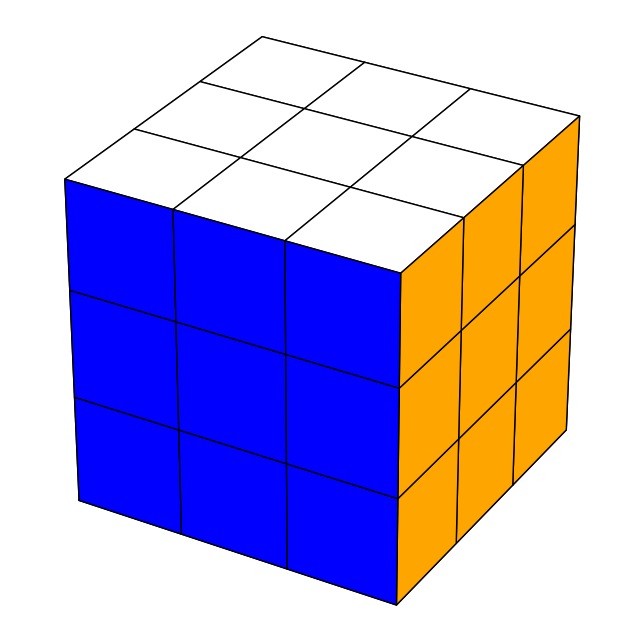

In [93]:
print(cube.solved())
cube.show()